In [2]:
%pip install matplotlib
%pip install sentence_transformers


Note: you may need to restart the kernel to use updated packages.


d:\ifortwins\.venv\Scripts\python.exe: No module named pip


Note: you may need to restart the kernel to use updated packages.


d:\ifortwins\.venv\Scripts\python.exe: No module named pip


In [1]:
import matplotlib.pyplot as plt
import json
import numpy as np
from sentence_transformers import SentenceTransformer
import re

CORPUS_PATH = "data/raw/corpus.jsonl"
EMBED_MODEL = "all-MiniLM-L6-v2"

d:\ifortwins\iforrag\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

def load_docs(path):
    docs = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                docs.append(json.loads(line))
    return docs


In [3]:
docs = load_docs(CORPUS_PATH)
model = SentenceTransformer(EMBED_MODEL)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5674.46it/s]


In [4]:
def sliding_windows(text, window_size=100, step_size=50):
    """
    Splits text into overlapping windows of a specified size.
    
    Parameters:
    text (str): The input text to be split.
    window_size (int): The size of each window.
    step_size (int): The step size for sliding the window.
    
    Returns:
    list: A list of text windows.
    """
    windows = []
    for start in range(0, len(text), step_size):
        end = start + window_size
        windows.append(text[start:end])
        if end >= len(text):
            break
    return windows

In [ ]:

def split_sentences_punctuation(text):
    """
    Splits text into sentences using punctuation marks.
    
    Parameters:
    text (str): The input text to be split.
    
    Returns:
    list: A list of sentences.
    """
    # Regular expression to split sentences based on punctuation marks
    sentences = re.split(r'(?<=[.!?]) +', text)
    return sentences


In [5]:
chunks = []
for d in docs:
    windows = sliding_windows(d["text"], 100, 50)
    for i, c in enumerate(windows):
        chunks.append({"doc_id": d["id"], "sent_id": d["id"] + f"_w_{i}", "title": d["title"], "text": f"Title: {d['title']}\n{c}"})


In [6]:
print(chunks[-1])
print(f"Total chunks created: {len(chunks)}")


{'doc_id': 'DOC-16', 'sent_id': 'DOC-16_w_4', 'title': 'Sensor Data Logging', 'text': 'Title: Sensor Data Logging\nit of measure. Review the log for gaps after a network interruption.'}
Total chunks created: 78


In [7]:
vectors = model.encode([c["text"] for c in chunks])
vectors = np.asarray(vectors, dtype="float32")
vectors = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)

In [8]:
vectors.shape

(78, 384)

In [14]:
cos_scores=vectors @ vectors.T

In [21]:
rows, cols = np.where(cos_scores >= 0.8)

for i, j in zip(rows, cols):
    if i < j:
        if chunks[i]["doc_id"] == chunks[j]["doc_id"]:
            continue
        print("Score:", cos_scores[i,j])
        print("A:", chunks[i]["text"])
        print("A_id:", chunks[i]["doc_id"])
        print("B:", chunks[j]["text"])
        print("B_id:", chunks[j]["doc_id"])
        print(i, j)

Score: 0.8358182
A: Title: Fan F-30 — Vibration Limits
For F-30 axial fan units, the acceptable vibration velocity limit is 4.5 mm/s RMS measured at the be
A_id: DOC-05
B: Title: Vibration Note — F-30 Units
On F-30 fans, keep the vibration velocity at or below 4.5 mm/s RMS at the bearing. If the value rise
B_id: DOC-06
23 27
Score: 0.8640927
A: Title: Fan F-30 — Vibration Limits
 velocity limit is 4.5 mm/s RMS measured at the bearing housing. Readings above this level indicate 
A_id: DOC-05
B: Title: Vibration Note — F-30 Units
On F-30 fans, keep the vibration velocity at or below 4.5 mm/s RMS at the bearing. If the value rise
B_id: DOC-06
24 27


In [ ]:
rows, cols = np.where(cos_scores >= 0.8)

for i, j in zip(rows, cols):
    if i < j:
        print("Score:", cos_scores[i,j])
        print("A:", chunks[i]["text"])
        print("B:", chunks[j]["text"])

Score: 0.90782285
A: Title: Pump P-200 — Maintenance Schedule
 not exceed the rated pressure; for this unit the maximum operating pressure is 12 bar. Replace the 
B: Title: Pump P-200 — Maintenance Schedule
maximum operating pressure is 12 bar. Replace the seal kit if leakage is observed. Record vibration 
Score: 0.90308845
A: Title: Compressor C-100 — Specifications
The C-100 is a rotary screw air compressor. Rated output is 6 m3/min at 8 bar. Motor power is 37 kW.
B: Title: Compressor C-100 — Specifications
output is 6 m3/min at 8 bar. Motor power is 37 kW. It includes an integrated air-oil separator and a
Score: 0.90145534
A: Title: Motor M-50 — Startup Procedure
Before starting the M-50 electric motor, confirm the isolation switch is off, verify insulation resi
B: Title: Motor M-50 — Startup Procedure
he isolation switch is off, verify insulation resistance, and ensure the coupling guard is fitted. S
Score: 0.9043898
A: Title: Vibration Note — F-30 Units
low 4.5 mm/s RMS at the bea

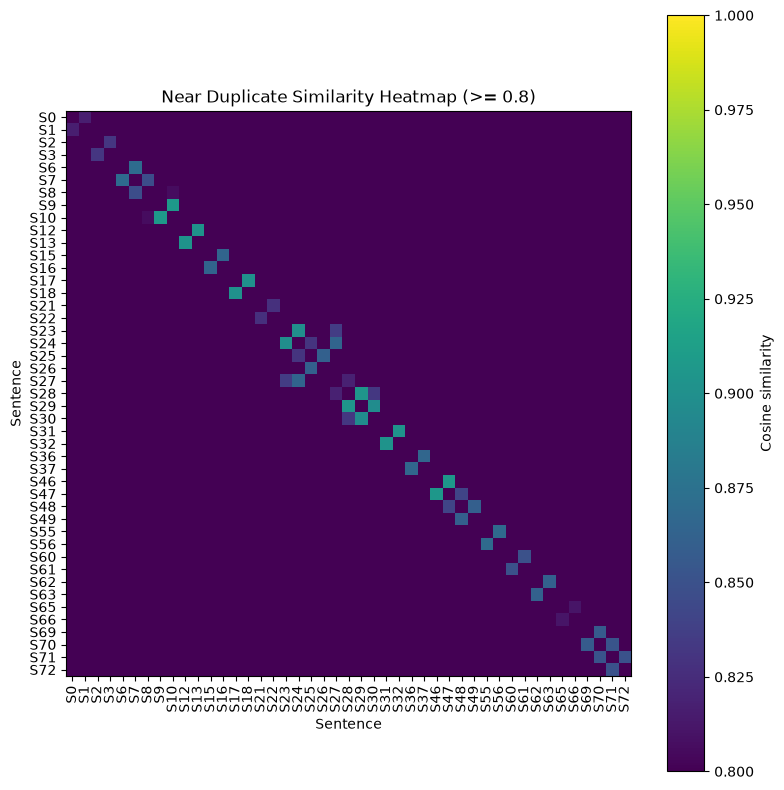

In [16]:
threshold = 0.80

# similarity = vectors @ vectors.T

# Remove self similarity
sim = np.asarray(cos_scores, dtype="float32").copy()
np.fill_diagonal(sim, 0)

# Find sentences that have at least one near-duplicate
keep = np.any(sim >= threshold, axis=1)

# Filter matrix
filtered_sim = sim[np.ix_(keep, keep)]

# Filter labels
filtered_labels = [
    f"S{i}"
    for i, k in enumerate(keep)
    if k
]

# Plot
plt.figure(figsize=(8, 8))

plt.imshow(
    filtered_sim,
    interpolation="nearest",
    vmin=threshold,
    vmax=1
)

plt.colorbar(
    label="Cosine similarity"
)

plt.xticks(
    range(len(filtered_labels)),
    filtered_labels,
    rotation=90
)

plt.yticks(
    range(len(filtered_labels)),
    filtered_labels
)

plt.xlabel("Sentence")
plt.ylabel("Sentence")

plt.title(
    f"Near Duplicate Similarity Heatmap (>= {threshold})"
)

plt.tight_layout()

plt.savefig(
    "similarity_heatmap_near_duplicates.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
print("there are two pairs of sentences that are near duplicate A: " + str(chunks[8]["doc_id"]) + " and " + str(chunks[2]["doc_id"]))
print("the text for pair A is: \n 1: " + str(chunks[8]["text"]) + " \n 2: " + str(chunks[2]["text"]))

there are two pairs of sentences that are near duplicate A: DOC-02_s_2 and DOC-01_s_2
the text for pair A is: 
 1: Do not exceed the rated pressure; for this unit the maximum operating pressure is 12 bar. 
 2: The maximum operating pressure is 16 bar.


In [ ]:
print("there are two pairs of sentences that are near duplicate A: " + str(chunks[21]["doc_id"]) + " and " + str(chunks[24]["doc_id"]))
print("the text for pair A is: \n 1: " + str(chunks[21]["text"]) + " \n 2: " + str(chunks[24]["text"]))

there are two pairs of sentences that are near duplicate A: DOC-05_s_0 and DOC-06_s_0
the text for pair A is: 
 1: For F-30 axial fan units, the acceptable vibration velocity limit is 4.5 mm/s RMS measured at the bearing housing. 
 2: On F-30 fans, keep the vibration velocity at or below 4.5 mm/s RMS at the bearing.
